# Questão 1
Existem valores faltantes ou outliers no dataset? Se sim, como você abordaria o
tratamento dessas inconsistências? Explique as técnicas que utilizaria para lidar
com essas questões

Sim, ambos existem no data set, trabalharei neles agora

## Identificações iniciais

imports

In [44]:
import csv
import pandas as pd
import numpy as np
from scipy.stats import mstats as sts
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import accuracy_score as AS

Primeiro análise de dados faltantes.

In [7]:
with open('diabetes.csv', 'r') as file:
  leitor = csv.reader(file)
  cabeçalho = next(leitor)
  i=0
  for linha in leitor:
    for item in linha:
      if item == '':
        i+=1
  print(i)

49


Localizar dados faltantes:

In [12]:
with open('diabetes.csv', 'r') as file:
  leitor = csv.reader(file)
  cabeçalho = next(leitor)
  i=0
  for i, linha in enumerate(leitor):
    for j, item in enumerate(linha):
      if item == '':
        print(f"Linha {i+1}, Coluna {j+1}: Dado faltante")
        print(f"Dado Faltante: {cabeçalho[j]}\n")

Linha 17, Coluna 6: Dado faltante
Dado Faltante: BMI

Linha 19, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 25, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 51, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 51, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 74, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 98, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 129, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 285, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 287, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 291, Coluna 7: Dado faltante
Dado Faltante: DiabetesPedigreeFunction

Linha 321, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 324, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 612, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 613, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 614, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 61

Traduzir em panda

In [18]:
# ds=Data Set
ds = pd.read_csv('diabetes.csv')

# ms = missing data

ms=ds.isna()

for i in range(len(ds)):
    for j, col in enumerate(ds.columns):
      if ms.iloc[i, j]:
        print(f"Linha {i+1}, Coluna {j+1}: Dado faltante")
        print(f"Dado Faltante: {col}\n")

Linha 17, Coluna 6: Dado faltante
Dado Faltante: BMI

Linha 19, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 25, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 51, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 51, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 74, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 98, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 129, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 285, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 287, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 291, Coluna 7: Dado faltante
Dado Faltante: DiabetesPedigreeFunction

Linha 321, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 324, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 612, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 613, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 614, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 61

estudo de dado outlier:

"Em estatística, outlier, valor aberrante ou valor atípico, é uma observação que apresenta um grande afastamento das demais da série, ou que é inconsistente. A existência de outliers implica, tipicamente, em prejuízos à interpretação dos resultados dos testes estatísticos aplicados às amostras."

In [29]:
# cn = coluna numérica
cn = ds.select_dtypes(include=['int64', 'float64']).columns

for coluna in cn:
  q1 = ds[coluna].quantile(0.25)
  q3 = ds[coluna].quantile(0.75)
  qr = q3-q1

  # ls = limite superior; li = limite inferior
  li = q1 - 1.5*qr
  ls = q3 + 1.5*qr

  # LcO = Localização de Outliers.
  # LcO indentifica se o item dela está maior ou menor que o 'permitido' em ls ou li
  LcO = ds[((ds[coluna]<li) | (ds[coluna]>ls))]

  print(f"\nOutliers em {coluna}: {len(LcO)}")
  print(LcO[[coluna]])


Outliers em Pregnancies: 4
     Pregnancies
88            15
159           17
298           14
455           14

Outliers em Glucose: 5
     Glucose
75       0.0
182      0.0
342      0.0
349      0.0
502      0.0

Outliers em BloodPressure: 44
     BloodPressure
7              0.0
15             0.0
18            30.0
43           110.0
49             0.0
60             0.0
78             0.0
81             0.0
84           108.0
106          122.0
125           30.0
172            0.0
177          110.0
193            0.0
222            0.0
261            0.0
266            0.0
269            0.0
300            0.0
332            0.0
336            0.0
347            0.0
357            0.0
362          108.0
426            0.0
430            0.0
435            0.0
453            0.0
468            0.0
484            0.0
494            0.0
522            0.0
533            0.0
535            0.0
549          110.0
589            0.0
597           24.0
601            0.0
604          

Tratamento de Outliers:
1. Irei fazer uma remoção de outliers e farei o cálculo sem eles
2. depois farei uma transformação para 'ajeitar' os outliers e aí sim fazer o cálculo com eles mais uma vez para fazer uma comparação.


Tratamento de falta de Info:
1. Não utilizarei as partes faltantes, pois, contrário do outlier, dados faltantes podem ser tanto 0 quanto $\infty$.

## Remoção de Outliers


In [35]:
def remocao_de_outliers(ds, colunas):
  ds_limpo = ds.copy()
  for coluna in colunas:
    q1 = ds[coluna].quantile(0.25)
    q3 = ds[coluna].quantile(0.75)
    qr = q3-q1

  # ls = limite superior; li = limite inferior
    li = q1 - 1.5*qr
    ls = q3 + 1.5*qr

  # remove todos os outliers
    ds_limpo = ds_limpo[(ds_limpo[coluna]>=li) & (ds_limpo[coluna]<=ls)]
  return ds_limpo

colunas_num = ds.select_dtypes(include=['int64', 'float64']).columns.drop('Outcome')
ds_sem_out = remocao_de_outliers(ds, colunas_num)

x = ds_sem_out.drop('Outcome', axis=1)
y = ds_sem_out['Outcome']

#utiliza uma rede neural para descobrir se tem ou nao uma diabete de forma mais precisa.
modelo = LR(max_iter=1000)
modelo.fit(x, y)
preds = modelo.predict(x)

print(f"Acurácia SEM outliers: {AS(y, preds)}")
print("\nExemplo das primeiras 10 classificações:")
print(pd.DataFrame({
    'Real': y.head(10),
    'Predito': preds[:10]
}))

Acurácia SEM outliers: 0.7926421404682275

Exemplo das primeiras 10 classificações:
    Real  Predito
0      1        1
1      0        0
2      1        1
3      0        0
5      0        0
6      1        0
10     0        0
11     1        1
14     1        1
17     1        0


## Tratamento de Outliers

In [43]:
ds_tratado = ds.copy()
colunas_numericas = ds.select_dtypes(include=['int64', 'float64']).columns.drop('Outcome')
for coluna in colunas_numericas:
    ds[coluna] = sts.winsorize(ds[coluna], limits=[0.05, 0.05])

# Preparar dados
X = ds.drop('Outcome', axis=1)
y = ds['Outcome']

# Treinar modelo
modelo = LR(max_iter=1000)
modelo.fit(X, y)

ds['Predicao_Diabetes'] = modelo.predict(X)

print(ds[['Outcome', 'Predicao_Diabetes']].head(20))

    Outcome  Predicao_Diabetes
0         1                  1
1         0                  0
2         1                  1
3         0                  0
4         1                  1
5         0                  0
6         1                  0
7         0                  1
8         1                  1
9         1                  0
10        0                  0
11        1                  1
12        0                  1
13        1                  1
14        1                  1
15        1                  0
16        1                  0
17        1                  0
18        0                  0
19        1                  0


# Questão 2:
Como as principais variáveis (Glucose, BloodPressure, BMI, etc.) estão
distribuídas? Utilize histogramas e boxplots para representar visualmente essas
distribuições e analise as características de cada uma.


## Boxplots:

imports

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

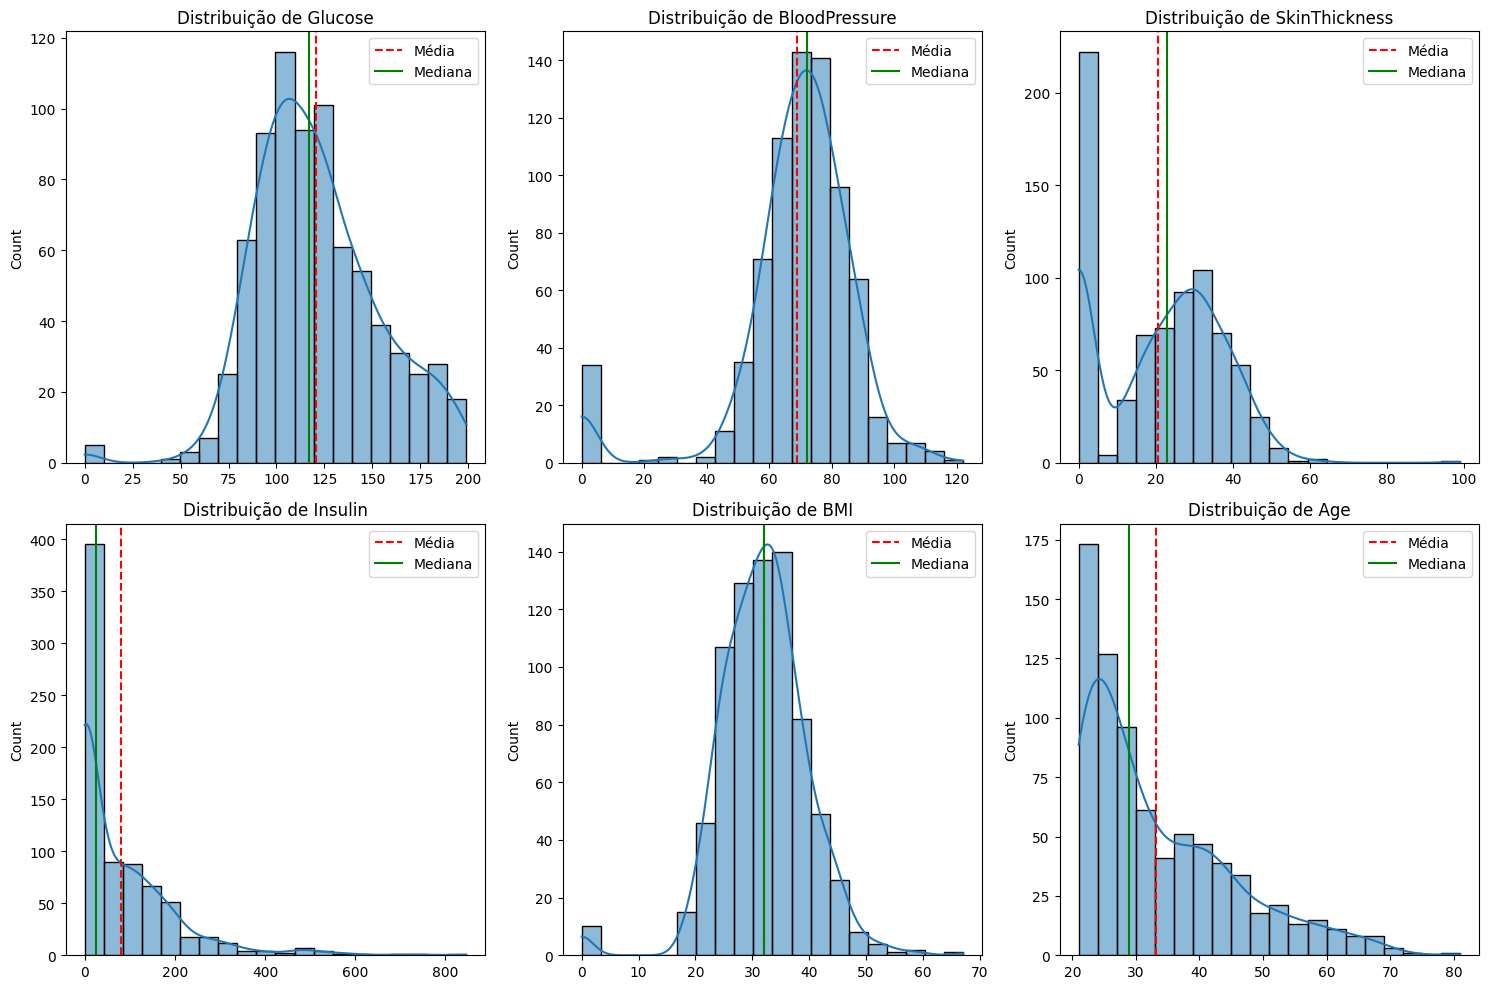

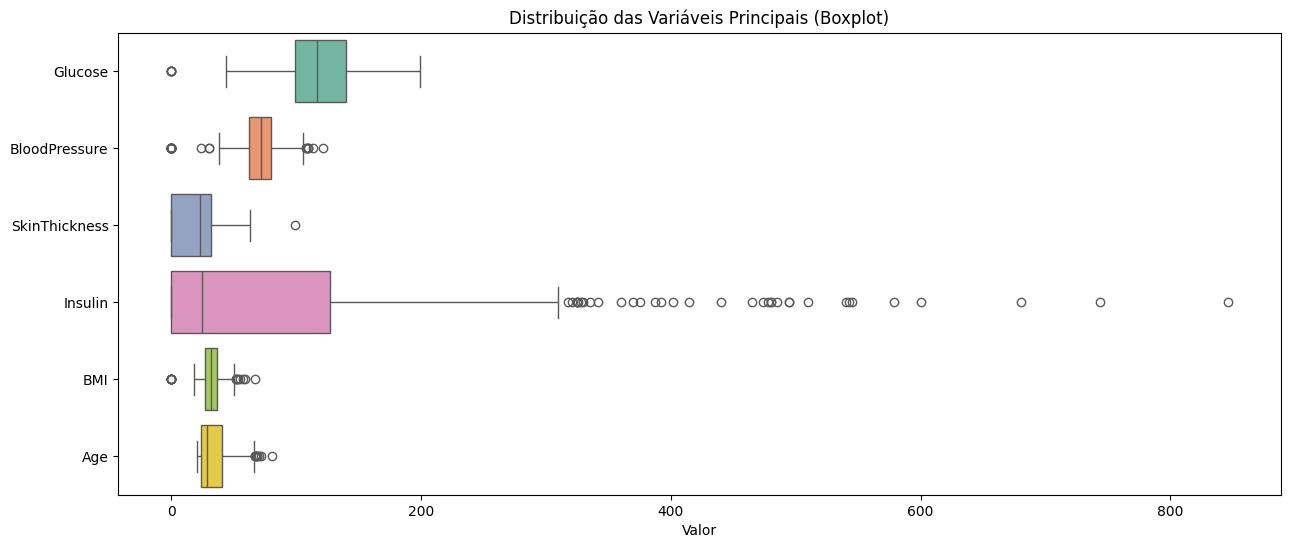

In [46]:
ds = pd.read_csv('diabetes.csv')

# Selecionar as principais variáveis
variaveis = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

# Configuração dos gráficos
plt.figure(figsize=(15, 10))

# Histogramas
for i, var in enumerate(variaveis, 1):
    plt.subplot(2, 3, i)
    sns.histplot(ds[var], kde=True, bins=20)
    plt.title(f'Distribuição de {var}')
    plt.xlabel('')
    plt.axvline(ds[var].mean(), color='r', linestyle='--', label='Média')
    plt.axvline(ds[var].median(), color='g', linestyle='-', label='Mediana')
    plt.legend()

plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 6))
sns.boxplot(data=ds[variaveis], orient='h', palette='Set2')
plt.title('Distribuição das Variáveis Principais (Boxplot)')
plt.xlabel('Valor')
plt.show()

## Análise:

1. Glucose:
 - Distribuida em picos com ~100ml sendo normal e ~140ml sendo alterado.
 - Assimétrico à direita.
2. Blood Pressure:
 - assimétrica à esquerda.
 - diversos dados faltantes, tendo um pico em 0.
3. skin thickness:
 - assimétrica à esquerda.
 - pico em 0.
4. insulin:
 - MUITO assimétrica.
 - grande concentração em 0.
5. BMI:
 - bem distríbuida, com assimetria fútil à direita.
6. Age:
 - assimétrica à direita.
 - pico em 20.
